In [ ]:
import pandas as pd
import numpy as np

#criação de um dataset simulado com anomalias propositais
dados_brutos = {
    "cliente_id": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "idade": [25, 32, -4, 45, np.nan, 29, 38, 999, 52, 22],
    "renda_mensal": [2500.0, 4200.0, 3100.0, np.nan, 5800.0, 3900.0, 15000000.0, 6100.0, 8500.0, 2100.0],
    "escolaridade": ["Superior", "Médio", "Superior", "Fundamental", "Superior", "Médio", "Superior", "Médio", "Pós-Graduação", "Médio"],
    "cidade": ["Campinas", "São Paulo", "Santos", "São Paulo", "Campinas", np.nan, "São Paulo", "Santos", "Campinas", "São Paulo"],
    "inadimplente": [0, 0, 1, 1, 0, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(dados_brutos)
print("---Primeiras linhas do Dataframe Bruto---")
print(df.head())


Primeiras linhas do Dataframe Bruto
   cliente_id  idade  renda_mensal escolaridade     cidade  inadimplente
0         101   25.0        2500.0     Superior   Campinas             0
1         102   32.0        4200.0        Médio  São Paulo             0
2         103   -4.0        3100.0     Superior     Santos             1
3         104   45.0           NaN  Fundamental  São Paulo             1
4         105    NaN        5800.0     Superior   Campinas             0


Obs: np.nan é um valor nulo

In [7]:
print("Informações estruturais do DataFrame")
df.info()

Informações estruturais do DataFrame
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cliente_id    10 non-null     int64  
 1   idade         9 non-null      float64
 2   renda_mensal  9 non-null      float64
 3   escolaridade  10 non-null     str    
 4   cidade        9 non-null      str    
 5   inadimplente  10 non-null     int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 612.0 bytes


In [ ]:
print("Resumo estatistico das variaveis numericas")
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
df.describe()

Resumo estatistico das variaveis numericas


,cliente_id,idade,renda_mensal,inadimplente
count,10.00000,9.000000,9.000000e+00,10.000000
mean,105.50000,137.555556,1.670689e+06,0.400000
std,3.02765,323.432803,4.998492e+06,0.516398
min,101.00000,-4.000000,2.100000e+03,0.000000
25%,103.25000,25.000000,3.100000e+03,0.000000
50%,105.50000,32.000000,4.200000e+03,0.000000
75%,107.75000,45.000000,6.100000e+03,1.000000
max,110.00000,999.000000,1.500000e+07,1.000000


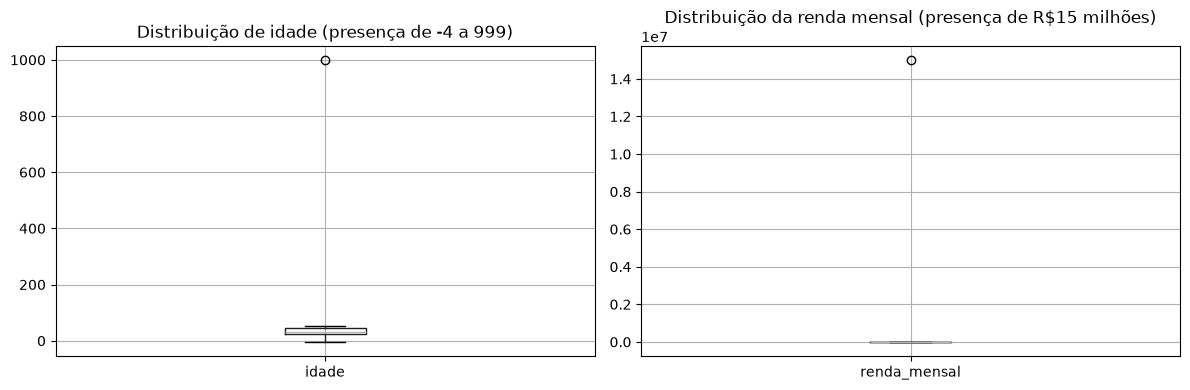

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column=["idade"], ax=axes[0])
axes[0].set_title("Distribuição de idade (presença de -4 a 999)")

df.boxplot(column=["renda_mensal"], ax=axes[1])
axes[1].set_title("Distribuição da renda mensal (presença de R$15 milhões)")

plt.tight_layout()
plt.show()

#Gráficos para indicar pontos fora da curva

In [13]:
nulos_por_coluna = df.isna().sum()
print("Quantidade de Nulos por Coluna")
print(nulos_por_coluna)


Quantidade de Nulos por Coluna
cliente_id      0
idade           1
renda_mensal    1
escolaridade    0
cidade          1
inadimplente    0
dtype: int64


In [ ]:
#Tratando colunas nulas
df_limpo = df.copy()

#1. Variável (cidade) pela moda
#preencher os nulos com a moda da coluna escolhida (cidade)
moda_cidade = df_limpo["cidade"].mode()[0]
df_limpo["cidade"] = df_limpo["cidade"].fillna(moda_cidade)

#2. Renda mensal pela mediana dos valores
mediana_renda = df_limpo.loc[df_limpo["renda_mensal"]<1000000, "renda_mensal"].median()
df_limpo["renda_mensal"] = df_limpo["renda_mensal"].fillna(mediana_renda)

#3. Correção das idades inválidas (nulas) pela mediana (18 a 120 anos) **********CONFERIR
filtro_idade_valida = (df_limpo["idade"] >= 18) & (df_limpo["idade"] <= 120)
mediana_idade = df_limpo.loc[filtro_idade_valida, "idade"].median()
df_limpo.loc[~filtro_idade_valida, "idade"] = mediana_renda

#4. Remoção de renda absurda(acima de R$ 1.000.000 neste contexto)
df_limpo = df_limpo[df_limpo["renda_mensal"] < 1000000].reset_index(drop=True)


print("DataFrame após tratamento de nulos")
print(df_limpo[["cliente_id", "idade", "renda_mensal", "cidade"]])

DataFrame após tratamento de nulos
   cliente_id   idade  renda_mensal     cidade
0         101    25.0        2500.0   Campinas
1         102    32.0        4200.0  São Paulo
2         103  4050.0        3100.0     Santos
3         104    45.0        4050.0  São Paulo
4         105  4050.0        5800.0   Campinas
5         106    29.0        3900.0  São Paulo
6         108  4050.0        6100.0     Santos
7         109    52.0        8500.0   Campinas
8         110    22.0        2100.0  São Paulo


In [ ]:
#Tratando as categorias de texto para numérico

#Aplicação de One-hot encoding na cidade
df_processado = pd.get_dummies(df_limpo, columns=["cidade"], dtype=int)

#Codificação ordinal para escolaridade
mapeamento_escolaridade = {
    "Fundamental": 0,
    "Médio": 1,
    "Superior": 2,
    "Pós graduação": 3
}
df_processado["escolaridade"] = df_processado["escolaridade"].map(mapeamento_escolaridade)

#Remover cliente_id (não faz sentido treinar a IA com esta informação)
df_processado = df_processado.drop(columns=["cliente_id"])

print("Matriz processada pronta para escalonamento")
print(df_processado.head())

#

Matriz processada pronta para escalonamento
    idade  renda_mensal  escolaridade  inadimplente  cidade_Campinas  \
0    25.0        2500.0           2.0             0                1   
1    32.0        4200.0           1.0             0                0   
2  4050.0        3100.0           2.0             1                0   
3    45.0        4050.0           0.0             1                0   
4  4050.0        5800.0           2.0             0                1   

   cidade_Santos  cidade_São Paulo  
0              0                 0  
1              0                 1  
2              1                 0  
3              0                 1  
4              0                 0  


In [26]:
from sklearn.neighbors  import KNeighborsClassifier ##classe pronta para classificação dentro do KNN
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#Base de treino X1 = Anos de Relacionamento (Escala de 1.0 a 10.0 anos)
#X2 = Renda mensal declarada (Escala de R$2.800 a R$16.000)
X_bruto = np.array([
    [1.0, 3000.0],
    [1.5, 2980.0],
    [2.0, 3020.0],
    [8.0, 3500.0],
    [8.5, 3600.0],
    [9.0, 3400.0],
    [1.0, 15000.0],
    [2.0, 16000.0]
    ])

# Classe : 0 (Crédito negado), 1 (Crédito aprovado)
y = np.array([0, 0, 0, 1, 1, 1, 1, 1])

# Novo cliente : 8.5 anos de conta e R$3.010 de renda (Deveria ser aprovado = 1)
novo_cliente = np.array([[8.5, 3010.0]])

In [ ]:
knn_sem_escala = KNeighborsClassifier(n_neighbors=3)
knn_sem_escala.fit(X_bruto, y)

pred_sem_escala = knn_sem_escala.predict(novo_cliente)
distancias_sem_escala, indices_sem_escala = knn_sem_escala.kneighbors(novo_cliente)

print("=" * 60)
print("    KNN SEM ESCALONAMENTO  (DADOS BRUTOS)                  ")
print("=" * 60)
print(f"Novo cliente: {novo_cliente} (8.5 anos e  R$3.010 de renda)")
print(f"Classe predita: {pred_sem_escala[0]} (Esperado 1)")
print(f"Vizinhos selecionados (índices): {indices_sem_escala[0]}")
print(f"Distancias calculadas: {distancias_sem_escala[0]}")

#Como os dados não estão escalonados, ele diz que a classe prevista é 0 (a distancia das rendas é diferente, fora de escala)

    KNN SEM ESCALONAMENTO  (DADOS BRUTOS)                  
Novo cliente: [[   8.5 3010. ]] (8.5 anos e  R$3.010 de renda)
Classe predita: 0 (Esperado 1)
Vizinhos selecionados (índices): [2 0 1]
Distancias calculadas: [11.92686044 12.5        30.8058436 ]
